In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
def initialize_atoms(atom_number=10, F_state=1, n=1000):
    atoms = np.zeros((atom_number, 2))
    for a in atoms:
        a[0] = F_state  # Hyperfine state
        a[1] = n        # vibrational quantum number
    return atoms

def raman(atoms, cool_on_F1=True):
    for a in atoms:
        if a[0] == 1:
            a[0] = 2
            if cool_on_F1:
                a[1] -= 1 if a[1] > 0 else 0
            else:
                a[1] += 1
        elif a[0] == 2:
            a[0] = 1
            if cool_on_F1:
                a[1] += 1 
            else:
                a[1] -= 1 if a[1] > 0 else 0
    return atoms

def pump(atoms, pump_connection=[1,1]):
    for a in atoms:
        # only works of ground HF state is correct
        if a[0] == pump_connection[0]:
            # if decay from F'=1, then 5/6 chance go to F=2, 1/6 to F=1
            if pump_connection[1] == 1:
                a[0]=2 if np.random.rand()<5/6 else 1
            # if decay from F'=2, then 1/2 chance go to F=2, 1/2 to F=1
            elif pump_connection[1] == 2:
                a[0]=2 if np.random.rand()<1/2 else 1
    return atoms

def RSC(atoms, cool_on_F1=True, pump_connection = [1,1], cycles=100):
    if cool_on_F1:
        print(f"Cooling on F=1. Optical pumping connects F={pump_connection[0]} to F'={pump_connection[1]}")
    else:
        print(f"Cooling on F=2. Optical pumping connects F={pump_connection[0]} to F'={pump_connection[1]}")
    
    average_n = np.array([np.mean(atoms[:,1])])
    for _ in range(cycles):
        atoms = raman(atoms=atoms, cool_on_F1=cool_on_F1)
        atoms = pump(atoms=atoms, pump_connection=pump_connection)
        average_n = np.append( average_n, np.mean(atoms[:,1]))

    return atoms, average_n

def compute_stats(atoms):
    F1_count = np.sum(atoms[:,0] == 1)
    F2_count = np.sum(atoms[:,0] == 2)
    avg_n = np.mean(atoms[:,1])
    return F1_count, F2_count, avg_n

In [2]:
n = 2000
atom_number = 100
cycles = 100

Starting RSC process...
Cooling on F=1. Optical pumping connects F=2 to F'=2
Cooling on F=2. Optical pumping connects F=1 to F'=1


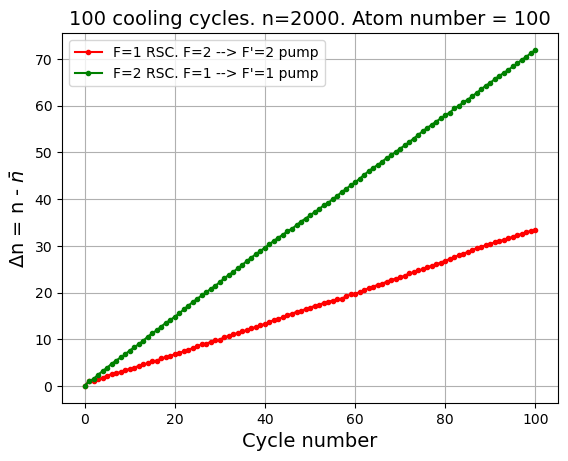

In [5]:
# calculate and plot
atoms_F1 = initialize_atoms(atom_number=atom_number, F_state=1, n=n)
atoms_F2 = initialize_atoms(atom_number=atom_number, F_state=2, n=n)

print("Starting RSC process...")
atoms_after_RSC_F1, avg_n_cool_F1 = RSC(atoms=atoms_F1, cool_on_F1 = True, pump_connection = [2,2], cycles=cycles)
atoms_after_RSC_F2, avg_n_cool_F2 = RSC(atoms=atoms_F2, cool_on_F1 = False, pump_connection = [1,1], cycles=cycles)

# plot average_n over the cooling cycle:
plt.plot(n - avg_n_cool_F1, '.-' , color = 'red',label = "F=1 RSC. F=2 --> F'=2 pump")
plt.plot(n - avg_n_cool_F2, '.-', color = 'green', label = "F=2 RSC. F=1 --> F'=1 pump")
plt.legend()
plt.xlabel('Cycle number', fontsize = 14)
plt.ylabel(r'$\Delta$n = n - $\bar{n}$', fontsize = 14)
plt.grid()
plt.title(f'{cycles} cooling cycles. n={n}. Atom number = {atom_number}', fontsize = 14)
plt.show()


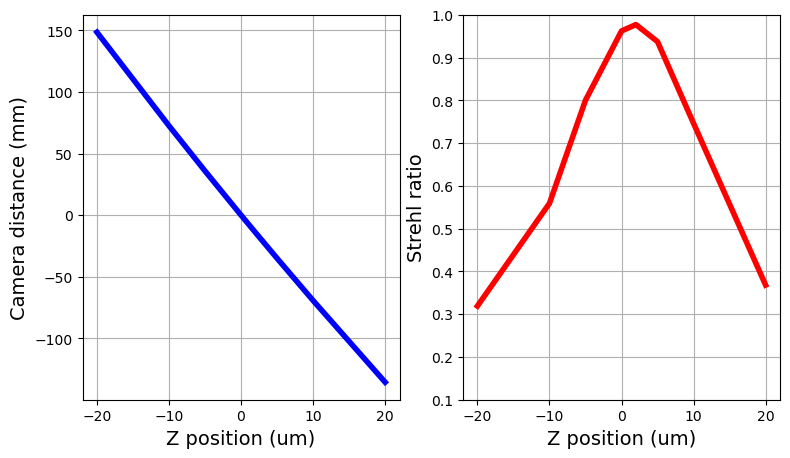

<Figure size 640x480 with 0 Axes>

In [9]:
# z_position_um = np.array([0, 10, 20, 30, 40, 50, 60, 70, -10, -20, -30, -40, -50, -60, -70, 100,-100])
# camera_distance_mm = np.array([3002.144, 2932.816, 2866.495, 2804.051, 2744.778, 2687.862, 2633.167,
#                                2580.565, 3067.901, 3141.476, 3218.526, 3299.301, 3384.078, 3473.159, 3566.880,
#                                2434.183, 3879.781,]) - 3002.144
# strehl_ratio = np.array([0.962, 0.746, 0.368, 0.297, 0.315, 0.249, 0.210, 0.210, 0.909, 0.571, 0.379, 0.391, 0.369, 0.290, 0.270,
#                          0.123, 0.211,])

z_position_um = np.array([0, 2, 5, 10, 20, -5, -10, -20])
camera_distance_mm = np.array([3002.144, 2988.028, 2967.092 , 2932.816, 2866.495, 3038.000 , 3074.686, 3150.670]) - 3002.144
strehl_ratio = np.array([0.962, 0.977, 0.937, 0.746, 0.368, 0.80, 0.559, 0.319])

# sort:
ind = np.argsort(z_position_um)
z_position_um = z_position_um[ind]
camera_distance_mm = camera_distance_mm[ind]
strehl_ratio = strehl_ratio[ind]

fig, axs = plt.subplots(1,2, figsize=(9, 5))
axs[0].plot(z_position_um, camera_distance_mm, linestyle = '-',  linewidth = 4, color = 'blue')
axs[1].plot(z_position_um, strehl_ratio, linestyle = '-',  linewidth = 4, color = 'red')
axs[0].grid()
axs[1].grid()
axs[0].set_xlabel('Z position (um)', fontsize = 14)
axs[1].set_xlabel('Z position (um)', fontsize = 14)
axs[0].set_ylabel('Camera distance (mm)', fontsize = 14)
axs[1].set_ylabel('Strehl ratio', fontsize = 14)
axs[1].set_ylim([0.1,1.0])
plt.show()
plt.tight_layout()